1. Problem Statement
2. Import Libraries
3. Data Loading
4. Data Understanding
5. Data Cleaning
6. EDA
7. Feature Engineering
8. Prepare Data for Modeling
9. Modeling
10. Evaluation
11. Conclusion
   

# House Price Prediction

## 1.Problem Statement
The goal of this project is to predict house sale prices based on various features such as size, quality, location, and other property attributes.

This is a supervised machine learning regression problem.
   

## 2. Import Libraries

In [142]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, r2_score

## 3. Data Loading

In [143]:
df = pd.read_csv("data/train.csv")
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


## 4. Data Understanding

In [144]:

# first look
print(df.head())

# shape of data
print("Shape:", df.shape)

# column names
print("Columns:")
print(df.columns)

# basic info
print(df.info())

# summary statistics
print(df.describe())

   Id  MSSubClass MSZoning  LotFrontage  LotArea Street Alley LotShape  \
0   1          60       RL         65.0     8450   Pave   NaN      Reg   
1   2          20       RL         80.0     9600   Pave   NaN      Reg   
2   3          60       RL         68.0    11250   Pave   NaN      IR1   
3   4          70       RL         60.0     9550   Pave   NaN      IR1   
4   5          60       RL         84.0    14260   Pave   NaN      IR1   

  LandContour Utilities  ... PoolArea PoolQC Fence MiscFeature MiscVal MoSold  \
0         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      2   
1         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      5   
2         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      9   
3         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      2   
4         Lvl    AllPub  ...        0    NaN   NaN         NaN       0     12   

  YrSold  SaleType  SaleCondition  SalePrice  
0   2008        WD   

In [145]:
#Check Missing Values (VERY IMPORTANT)
df.isnull().sum().sort_values(ascending=False)

PoolQC         1453
MiscFeature    1406
Alley          1369
Fence          1179
MasVnrType      872
               ... 
ExterQual         0
Exterior2nd       0
Exterior1st       0
RoofMatl          0
SalePrice         0
Length: 81, dtype: int64

## 5. Data Cleaning

In [146]:
#Step 3 — Data Preprocessing (Data Cleaning + Feature Preparation)
print(df.isnull().sum().sort_values(ascending=False).head(20))

#Strategy
#1. Drop columns with too many missing values
df = df.drop(columns=["Alley", "PoolQC", "Fence", "MiscFeature"])  # example

#Fill numeric columns
num_cols = df.select_dtypes(include=["int64", "float64"]).columns

for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

#Fill categorical columns
cat_cols = df.select_dtypes(include=["object"]).columns

for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

#Varify
print(df.isnull().sum().sum())

PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageYrBlt       81
GarageCond        81
GarageType        81
GarageFinish      81
GarageQual        81
BsmtFinType2      38
BsmtExposure      38
BsmtQual          37
BsmtCond          37
BsmtFinType1      37
MasVnrArea         8
Electrical         1
Id                 0
dtype: int64
0


## 6.Exploratory Data Analysis

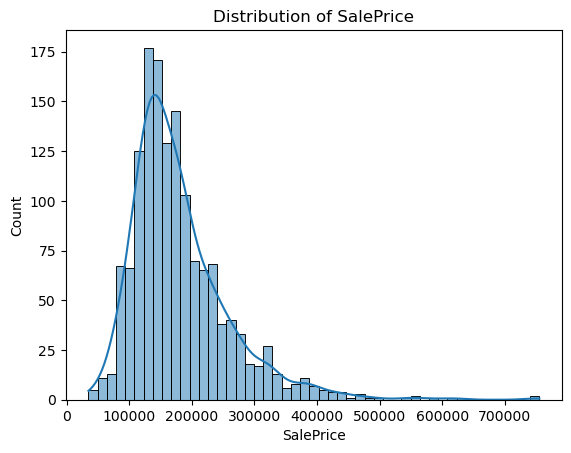

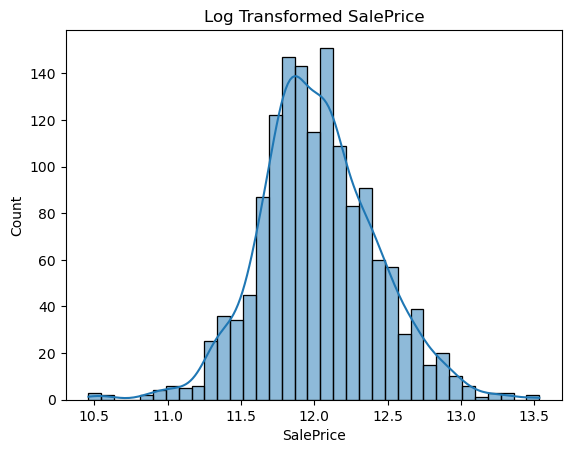

In [147]:

#Histogram 

sns.histplot(df["SalePrice"], kde=True)
plt.title("Distribution of SalePrice")
plt.show()

#Linear Regression works best when:target variable is approximately normally distributed

#Log Transformation

#What This Does
#Compresses large values
#Reduces skewness
#Makes distribution more “normal
import numpy as np
y = np.log(df["SalePrice"])
sns.histplot(y, kde=True)
plt.title("Log Transformed SalePrice")
plt.show()

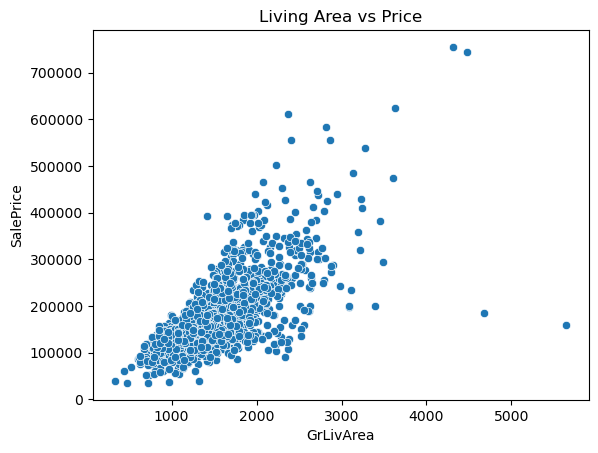

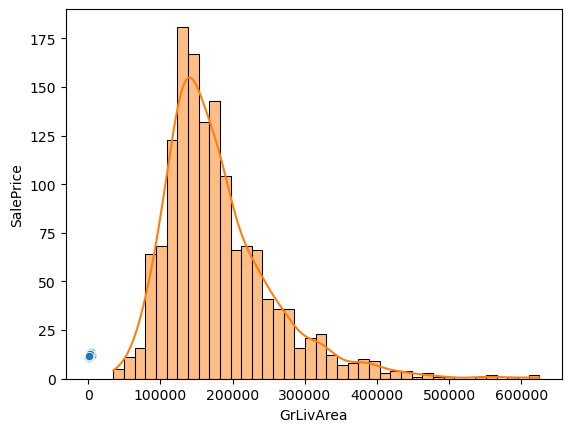

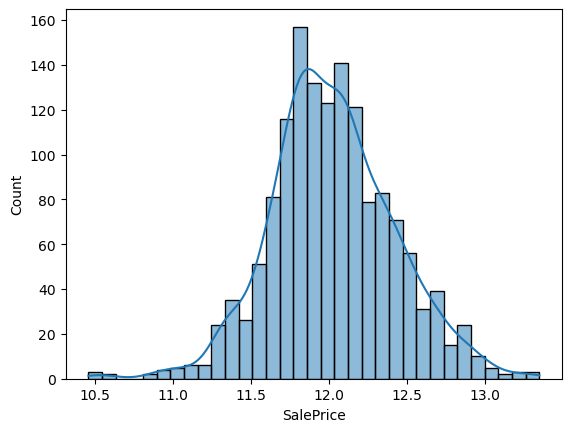

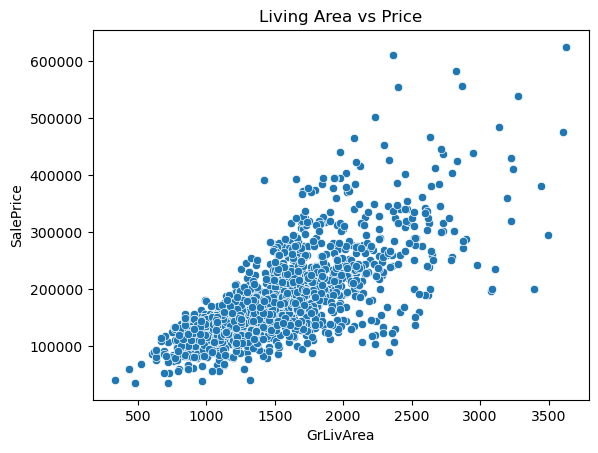

<Axes: xlabel='GrLivArea', ylabel='SalePrice'>

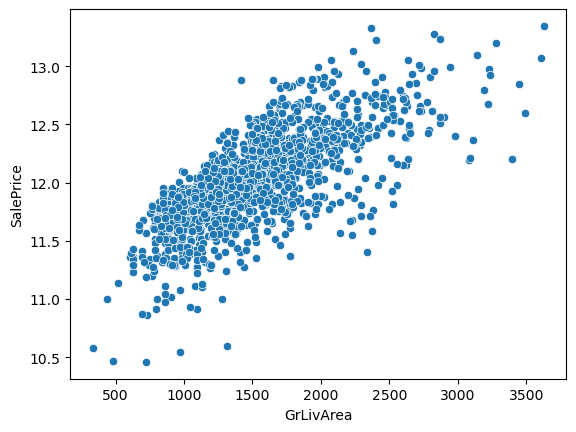

In [148]:
#Scatter Plot (Feature vs Target)
sns.scatterplot(x=df["GrLivArea"], y=df["SalePrice"])
plt.title("Living Area vs Price")
plt.show()
sns.scatterplot(x=df["GrLivArea"], y=np.log(df["SalePrice"]))
#Removing outliers
df = df[df["GrLivArea"] < 4000]
sns.histplot(df["SalePrice"], kde=True)
plt.show()

sns.histplot(np.log(df["SalePrice"]), kde=True)
plt.show()

sns.scatterplot(x=df["GrLivArea"], y=df["SalePrice"])
plt.title("Living Area vs Price")
plt.show()
sns.scatterplot(x=df["GrLivArea"], y=np.log(df["SalePrice"]))

## Correlation

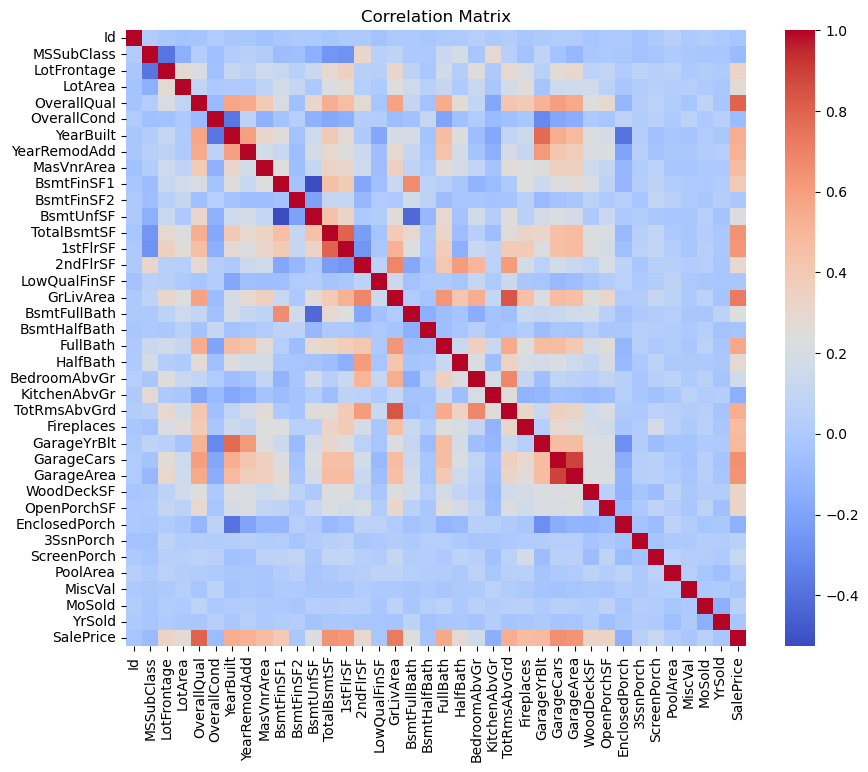

SalePrice        1.000000
OverallQual      0.800858
GrLivArea        0.720516
GarageCars       0.649256
TotalBsmtSF      0.646584
GarageArea       0.636964
1stFlrSF         0.625235
FullBath         0.559048
TotRmsAbvGrd     0.537462
YearBuilt        0.535279
YearRemodAdd     0.521428
GarageYrBlt      0.477961
MasVnrArea       0.473650
Fireplaces       0.466765
BsmtFinSF1       0.395923
LotFrontage      0.338149
OpenPorchSF      0.330361
WoodDeckSF       0.322538
2ndFlrSF         0.297301
HalfBath         0.282925
LotArea          0.269866
BsmtFullBath     0.235697
BsmtUnfSF        0.220678
BedroomAbvGr     0.160542
ScreenPorch      0.118324
MoSold           0.056797
3SsnPorch        0.047414
PoolArea         0.032819
BsmtFinSF2      -0.008900
MiscVal         -0.021097
YrSold          -0.023694
LowQualFinSF    -0.025351
Id              -0.027455
BsmtHalfBath    -0.036792
OverallCond     -0.080202
MSSubClass      -0.088160
EnclosedPorch   -0.129774
KitchenAbvGr    -0.138849
Name: SalePr

In [149]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(10,8))
sns.heatmap(corr, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()
print(corr["SalePrice"].sort_values(ascending=False))



## 7.Feature Engineering

## 8.Prepare Data for Modeling :  
## Data Preparation

In [150]:
#Define X and y
y = np.log(df["SalePrice"])
# features
X = df.drop("SalePrice", axis=1)

In [151]:
#Encode categorical variables

X = pd.get_dummies(X, drop_first=True)

In [152]:

#Train-Test Split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## 9. Modeling

## Linear Regression

In [153]:

model = LinearRegression()
model.fit(X_train, y_train)

#Predict

y_pred_log = model.predict(X_test)

# convert back to real price
y_pred = np.exp(y_pred_log)
y_test_actual = np.exp(y_test)

#Evaluate

rmse = np.sqrt(mean_squared_error(y_test_actual, y_pred))
r2 = r2_score(y_test_actual, y_pred)

print("RMSE:", rmse)
print("R2 Score:", r2)

#Feature Importance
coeff_df = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})

coeff_df["abs_coeff"] = coeff_df["Coefficient"].abs()
print(coeff_df.sort_values(by="abs_coeff", ascending=False).head(10))




RMSE: 20880.57398824828
R2 Score: 0.9169276641905684
                 Feature  Coefficient  abs_coeff
214        GarageQual_Po    -0.676929   0.676929
218        GarageCond_Po     0.608331   0.608331
91       Condition2_RRAe    -0.574935   0.574935
212        GarageQual_Fa    -0.454095   0.454095
37           MSZoning_FV     0.413265   0.413265
215        GarageQual_TA    -0.408397   0.408397
213        GarageQual_Gd    -0.395626   0.395626
109       RoofStyle_Shed     0.387562   0.387562
39           MSZoning_RL     0.377758   0.377758
117  Exterior1st_BrkComm    -0.352567   0.352567


## Improve the model 

In [154]:

#First Improvement Step

#Let’s simplify model:

#👉 Use only top features from correlation
top_features = ["OverallQual", "GrLivArea", "GarageCars", "TotalBsmtSF"]

X = df[top_features]
y = np.log(df["SalePrice"])


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred_log = model.predict(X_test)

y_pred = np.exp(y_pred_log)
y_test_actual = np.exp(y_test)

rmse = np.sqrt(mean_squared_error(y_test_actual, y_pred))
r2 = r2_score(y_test_actual, y_pred)

print("RMSE:", rmse)
print("R2 Score:", r2)



RMSE: 28765.071196054083
R2 Score: 0.8423469188815229


## Apply Ridge regression on improved model

In [155]:

ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)

y_pred_log = ridge.predict(X_test)
y_pred = np.exp(y_pred_log)

from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

rmse = np.sqrt(mean_squared_error(np.exp(y_test), y_pred))
r2 = r2_score(np.exp(y_test), y_pred)

print("RMSE:", rmse)
print("R2:", r2)

RMSE: 28768.017415134364
R2: 0.8423146224690198


## Apply Lasso regression on improved model

In [156]:

lasso = Lasso(alpha=0.001)  # small alpha to start
lasso.fit(X_train, y_train)

y_pred_log = lasso.predict(X_test)
y_pred = np.exp(y_pred_log)

from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

rmse = np.sqrt(mean_squared_error(np.exp(y_test), y_pred))
r2 = r2_score(np.exp(y_test), y_pred)

print("RMSE:", rmse)
print("R2:", r2)

coeff_df = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": lasso.coef_
})

# only non-zero features
selected_features = coeff_df[coeff_df["Coefficient"] != 0]
print(selected_features)



RMSE: 28798.579247481975
R2: 0.8419794089694473
       Feature  Coefficient
0  OverallQual     0.118587
1    GrLivArea     0.000251
2   GarageCars     0.099387
3  TotalBsmtSF     0.000205


## Apply Ridge regression on FULL dataset (all features)

In [157]:
#Apply Ridge on FULL dataset (all features)

X = df.drop("SalePrice", axis=1)
X = pd.get_dummies(X, drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)

y_pred_log = ridge.predict(X_test)
y_pred = np.exp(y_pred_log)

from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

rmse = np.sqrt(mean_squared_error(np.exp(y_test), y_pred))
r2 = r2_score(np.exp(y_test), y_pred)

print("RMSE:", rmse)
print("R2:", r2)

RMSE: 19949.555702243364
R2: 0.9241705314627416


## Apply Lasso regression on FULL dataset (all features)

In [158]:
#Apply Lasso on FULL dataset (all features)

import pickle
X = df.drop("SalePrice", axis=1)
X = pd.get_dummies(X, drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
# save training columns for API alignment later
with open("./models/model_columns.pkl", "wb") as f:
    pickle.dump(X.columns.tolist(), f)

# train model
lasso = Lasso(alpha=0.001, max_iter=10000)
lasso.fit(X_train, y_train)

# save trained model too
with open("./models/lasso_model.pkl", "wb") as f:
    pickle.dump(lasso, f)
    

y_pred_log = lasso.predict(X_test)
y_pred = np.exp(y_pred_log)

from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

rmse = np.sqrt(mean_squared_error(np.exp(y_test), y_pred))
r2 = r2_score(np.exp(y_test), y_pred)

print("RMSE:", rmse)
print("R2:", r2)

coeff_df = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": lasso.coef_
})

# only non-zero features
selected_features = coeff_df[coeff_df["Coefficient"] != 0]
print(selected_features)

RMSE: 19471.832215499457
R2: 0.9277587597059739
                  Feature  Coefficient
0                      Id    -0.000010
1              MSSubClass    -0.000294
2             LotFrontage     0.000406
3                 LotArea     0.000002
4             OverallQual     0.061232
..                    ...          ...
204        FireplaceQu_TA    -0.003728
211      GarageFinish_Unf    -0.004831
227          SaleType_New     0.114821
229           SaleType_WD    -0.004556
233  SaleCondition_Normal     0.065820

[73 rows x 2 columns]


## Random Forest 

In [159]:
#Random Forest 

from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

y_pred_log = rf.predict(X_test)
y_pred = np.exp(y_pred_log)

from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

rmse = np.sqrt(mean_squared_error(np.exp(y_test), y_pred))
r2 = r2_score(np.exp(y_test), y_pred)

print("RMSE:", rmse)
print("R2:", r2)

RMSE: 26251.05354833267
R2: 0.8686999074941372


## 10. Model Evaluation
Lasso regression performed better than standard linear regression by reducing overfitting and selecting relevant features.

## 11.Conclusion

- Lasso regression achieved the best performance (R² ~0.93)
- Regularization helped handle multicollinearity
- Using all features improved model performance compared to reduced feature sets

In [160]:
#import pickle

#with open("./models/lassofull_model.pkl", "wb") as f:
    #pickle.dump(lassofull, f)

In [161]:
import os
print(os.getcwd())

/Users/pramilasoni/house-price-prediction


## 1. Hyperparameter Tuning - Lasso Alpha
What tuning means

Lasso has a parameter called alpha.

small alpha → weaker penalty, keeps more features
large alpha → stronger penalty, removes more features

We want the alpha that gives the best balance:

low RMSE
high R²

What this does

For each alpha:

trains a new Lasso model
predicts on test data
converts predictions back from log scale
calculates RMSE and R²
stores results in a table
What you should look for

The best alpha usually has:

lowest RMSE
and a strong R²

Do not assume the old 0.001 is best. Let the results tell us.


In [162]:
from sklearn.linear_model import Lasso
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
import pandas as pd

alphas = [0.0001, 0.001, 0.01, 0.1, 1]
results = []

for alpha in alphas:
    lasso_tuned = Lasso(alpha=alpha, max_iter=10000)
    lasso_tuned.fit(X_train, y_train)

    y_pred_log = lasso_tuned.predict(X_test)
    y_pred = np.exp(y_pred_log)
    y_test_actual = np.exp(y_test)

    rmse = np.sqrt(mean_squared_error(y_test_actual, y_pred))
    r2 = r2_score(y_test_actual, y_pred)

    results.append({
        "alpha": alpha,
        "RMSE": rmse,
        "R2": r2
    })

results_df = pd.DataFrame(results)
results_df.sort_values(by="RMSE")

,alpha,RMSE,R2
1,0.0010,19471.832215,0.927759
0,0.0001,19654.609090,0.926396
2,0.0100,22837.434756,0.900628
3,0.1000,28155.816269,0.848954
4,1.0000,31803.641700,0.807281


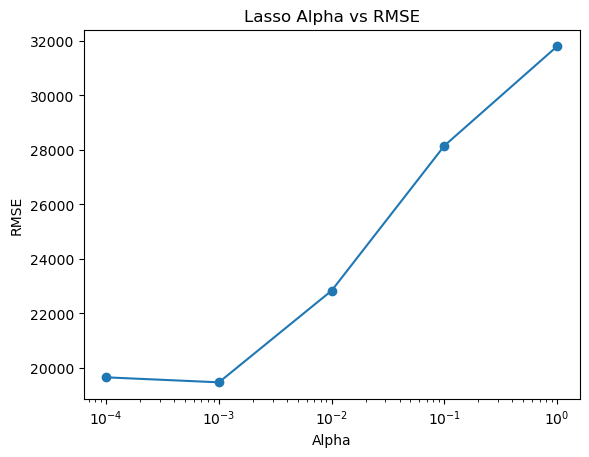

In [163]:
import matplotlib.pyplot as plt

plt.plot(results_df["alpha"], results_df["RMSE"], marker="o")
plt.xscale("log")
plt.xlabel("Alpha")
plt.ylabel("RMSE")
plt.title("Lasso Alpha vs RMSE")
plt.show()

## 2. Cross-Validation


I only used one train/test split

👉 But in real-world:

We validate across multiple splits

In [164]:
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import Lasso
import numpy as np

lasso_cv = Lasso(alpha=0.001, max_iter=10000)

scores = cross_val_score(
    lasso_cv,
    X,
    y,
    cv=5,
    scoring="r2"
)

print("Cross-validation R2 scores:", scores)
print("Mean R2:", np.mean(scores))

Cross-validation R2 scores: [0.91274176 0.91703497 0.9055514  0.91966836 0.90840874]
Mean R2: 0.9126810462190151


Outcome : What This Means
1. Model is Stable

    All scores are:

    ~0.90 – 0.92

    Very consistent 

    No big drops → model is reliable

2. No Overfitting

    Compare:

    Metric	Value
    Test R²	~0.928
    CV Mean R²	~0.913

    Small gap = GOOD

    If it was overfitting, I would see:
    Test R² = 0.95
    CV R² = 0.75  


   Big Conclusion

     model generalizes well
     Your tuning is correct
     Your pipeline is solid

What I have Just Achieved


✔ Clean pipeline
✔ Best alpha (0.001)
✔ Cross-validated model
✔ Strong performance (~0.91–0.93 R²)



## 3. Feature Engineering

In [169]:
df["TotalSF"] = df["TotalBsmtSF"] + df["1stFlrSF"] + df["2ndFlrSF"]
df["HouseAge"] = df["YrSold"] - df["YearBuilt"]
df["RemodAge"] = df["YrSold"] - df["YearRemodAdd"]
df["TotalBath"] = (
    df["FullBath"]
    + 0.5 * df["HalfBath"]
    + df["BsmtFullBath"]
    + 0.5 * df["BsmtHalfBath"]
)

In [170]:
X = df.drop("SalePrice", axis=1)
X = pd.get_dummies(X, drop_first=True)
print(X.columns.tolist())
# save training columns for API alignment later
with open("./models/model_columns.pkl", "wb") as f:
    pickle.dump(X.columns.tolist(), f)

# train model
lassofull = Lasso(alpha=0.001, max_iter=10000)
lassofull.fit(X_train, y_train)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

y_pred_log = lassofull.predict(X_test)
y_pred = np.exp(y_pred_log)

from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

rmse = np.sqrt(mean_squared_error(np.exp(y_test), y_pred))
r2 = r2_score(np.exp(y_test), y_pred)

print("RMSE:", rmse)
print("R2:", r2)



['Id', 'MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd', 'Fireplaces', 'GarageYrBlt', 'GarageCars', 'GarageArea', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea', 'MiscVal', 'MoSold', 'YrSold', 'TotalSF', 'HouseAge', 'RemodAge', 'TotalBath', 'MSZoning_FV', 'MSZoning_RH', 'MSZoning_RL', 'MSZoning_RM', 'Street_Pave', 'LotShape_IR2', 'LotShape_IR3', 'LotShape_Reg', 'LandContour_HLS', 'LandContour_Low', 'LandContour_Lvl', 'Utilities_NoSeWa', 'LotConfig_CulDSac', 'LotConfig_FR2', 'LotConfig_FR3', 'LotConfig_Inside', 'LandSlope_Mod', 'LandSlope_Sev', 'Neighborhood_Blueste', 'Neighborhood_BrDale', 'Neighborhood_BrkSide', 'Neighborhood_ClearCr', 'Neighborhood_CollgCr', 'Neighborhood_Cra

/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.621e-02, tolerance: 1.819e-02
  model = cd_fast.enet_coordinate_descent(


In [172]:
import pickle

with open("./models/lassofull_model.pkl", "wb") as f:
    pickle.dump(lassofull, f)

Now i have completed:

project structure
notebook cleanup
model training
Lasso tuning
cross-validation
feature engineering
model saving
simple API deployment
prediction testing


What You Just Built (Important)

You now have:

🔹 End-to-end ML system
Data → EDA
Feature engineering
Model training
Hyperparameter tuning
Cross-validation
Model persistence
API deployment
Input validation
Feature alignment

👉 This is real-world ML lifecycle

🔥 This is Portfolio-Level Work

You can now confidently say:

“I built and deployed a machine learning model using FastAPI, including feature engineering, model tuning, and inference pipeline alignment.”